<a href="https://colab.research.google.com/github/longlive13/Optimizing-Marketing-ROI-through-Customer-Segmentation-and-Channel-Strategy/blob/main/marketing_roi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd

In [1]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

client = bigquery.Client(project="marketing-roi-project")

In [2]:
queries = {
    "channel_roi_vs_conversion": """
    SELECT
        channel,
        AVG(converted) AS conversion_rate,
        AVG(roi) AS avg_roi,
        AVG(cost) AS avg_cost
    FROM `marketing-roi-project.bank_marketing.bank_processed`
    GROUP BY channel
    """,

    "revenue_by_balance_segment": """
    SELECT
        balance_segment,
        AVG(revenue) AS avg_revenue,
        SUM(revenue) AS total_revenue,
        AVG(converted) AS conversion_rate
    FROM `marketing-roi-project.bank_marketing.bank_processed`
    GROUP BY balance_segment
    """,

    "roi_by_campaign_frequency": """
    SELECT
        campaign_band,
        AVG(roi) AS avg_roi,
        AVG(converted) AS conversion_rate
    FROM `marketing-roi-project.bank_marketing.bank_processed`
    GROUP BY campaign_band
    """,

    "roi_by_segment_channel": """
    SELECT
        age_group,
        balance_segment,
        channel,
        AVG(roi) AS avg_roi,
        AVG(converted) AS conversion_rate
    FROM `marketing-roi-project.bank_marketing.bank_processed`
    GROUP BY age_group, balance_segment, channel
    """,

    "channel_role_analysis": """
    SELECT
        channel,
        AVG(converted) AS conversion_rate,
        AVG(revenue) AS avg_revenue,
        COUNT(*) AS volume
    FROM `marketing-roi-project.bank_marketing.bank_processed`
    GROUP BY channel
    """,

    "conversion_by_customer_type": """
    SELECT
        CASE
            WHEN previous = 0 THEN 'new'
            ELSE 'existing'
        END AS customer_type,
        AVG(converted) AS conversion_rate,
        AVG(roi) AS avg_roi
    FROM `marketing-roi-project.bank_marketing.bank_processed`
    GROUP BY customer_type
    """,

    "roi_by_call_duration": """
    SELECT
        CASE
            WHEN duration < 60 THEN 'short'
            WHEN duration < 180 THEN 'medium'
            ELSE 'long'
        END AS duration_group,
        AVG(converted) AS conversion_rate,
        AVG(roi) AS avg_roi
    FROM `marketing-roi-project.bank_marketing.bank_processed`
    GROUP BY duration_group
    """,

    "negative_roi_segments": """
    SELECT
        channel,
        age_group,
        balance_segment,
        AVG(roi) AS avg_roi
    FROM `marketing-roi-project.bank_marketing.bank_processed`
    GROUP BY channel, age_group, balance_segment
    HAVING AVG(roi) < 0
    """,

    "channel_cost_efficiency": """
    SELECT
        channel,
        SUM(cost) AS total_cost,
        SUM(revenue) AS total_revenue,
        SAFE_DIVIDE(SUM(revenue), SUM(cost)) AS roi
    FROM `marketing-roi-project.bank_marketing.bank_processed`
    GROUP BY channel
    """
}

In [3]:
results = {}

for name, query in queries.items():
    df = client.query(query).to_dataframe()
    results[name] = df

In [4]:
for name, df in results.items():
    print(f"\n===== {name} =====")
    display(df)


===== channel_roi_vs_conversion =====


,channel,conversion_rate,avg_roi,avg_cost
0,Email,0.102400,6.065624,1.355157
1,SMS,0.123358,2.538038,3.301746
2,Phone,0.119573,-0.198100,14.063817



===== revenue_by_balance_segment =====


,balance_segment,avg_revenue,total_revenue,conversion_rate
0,low,4.965815,151800.0,0.099316
1,mid,7.681221,90600.0,0.153624
2,high,7.744995,22050.0,0.154900



===== roi_by_campaign_frequency =====


...

,duration_group,conversion_rate,avg_roi
0,long,0.202346,4.790119
1,short,0.001932,-0.943479
2,medium,0.038707,0.212197



===== negative_roi_segments =====


,channel,age_group,balance_segment,avg_roi
0,Phone,middle,low,-0.473310
1,Phone,middle,mid,-0.159376
2,Phone,senior,low,-0.236957
3,Phone,middle,high,-0.084676



===== channel_cost_efficiency =====


,channel,total_cost,total_revenue,roi
0,Email,14623.5,55250.0,3.778165
1,SMS,59580.0,111300.0,1.868077
2,Phone,230295.0,97900.0,0.425107


In [7]:
with pd.ExcelWriter("marketing_analysis_results.xlsx") as writer:
    for name, df in results.items():
        df.to_excel(writer, sheet_name=name, index=False)

In [8]:
from google.colab import files
files.download("marketing_analysis_results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

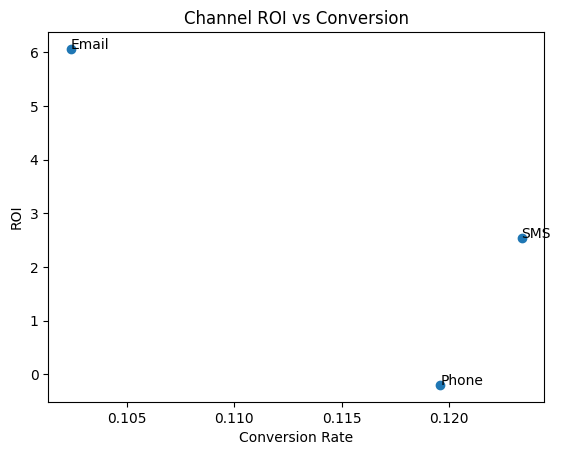

In [15]:
df = results["channel_roi_vs_conversion"]

plt.figure()
plt.scatter(df["conversion_rate"], df["avg_roi"])

for i, txt in enumerate(df["channel"]):
    plt.annotate(txt, (df["conversion_rate"][i], df["avg_roi"][i]))

plt.xlabel("Conversion Rate")
plt.ylabel("ROI")
plt.title("Channel ROI vs Conversion")

plt.savefig("channel_roi_vs_conversion.png")
plt.show()

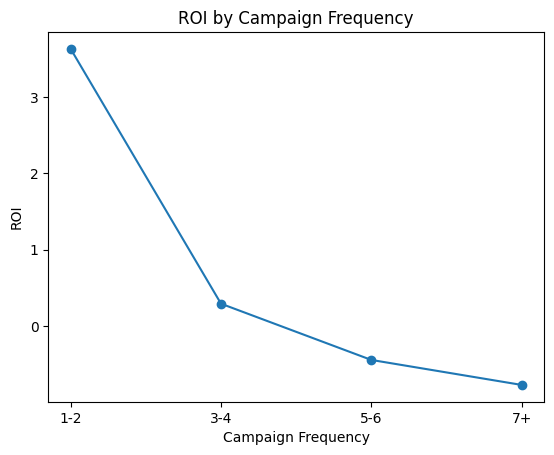

In [16]:
df = results["roi_by_campaign_frequency"]

plt.figure()
plt.plot(df["campaign_band"], df["avg_roi"], marker='o')

plt.xlabel("Campaign Frequency")
plt.ylabel("ROI")
plt.title("ROI by Campaign Frequency")

plt.savefig("roi_by_campaign_frequency.png")
plt.show()

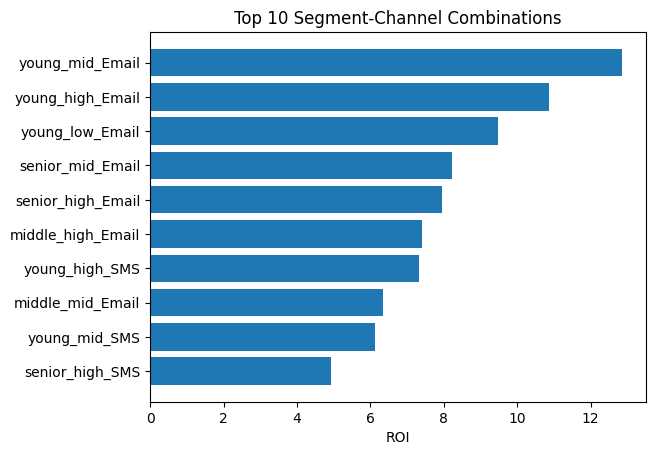

In [17]:
df = results["roi_by_segment_channel"]

df["segment"] = df["age_group"] + "_" + df["balance_segment"] + "_" + df["channel"]

top_df = df.sort_values("avg_roi", ascending=False).head(10)

plt.figure()
plt.barh(top_df["segment"], top_df["avg_roi"])

plt.xlabel("ROI")
plt.title("Top 10 Segment-Channel Combinations")

plt.gca().invert_yaxis()
plt.savefig("roi_by_segment_channel.png")
plt.show()

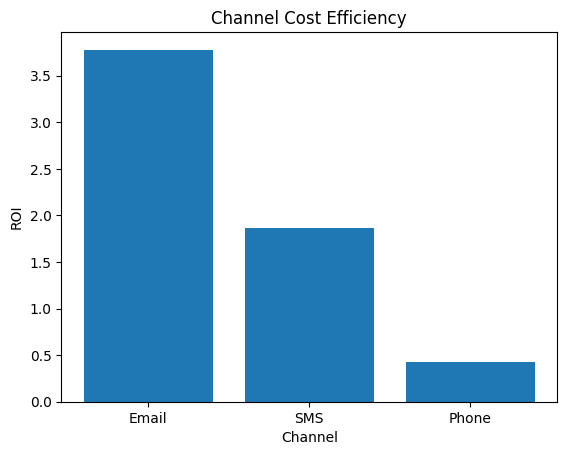

In [18]:
df = results["channel_cost_efficiency"]

plt.figure()
plt.bar(df["channel"], df["roi"])

plt.xlabel("Channel")
plt.ylabel("ROI")
plt.title("Channel Cost Efficiency")

plt.savefig("channel_cost_efficiency.png")
plt.show()

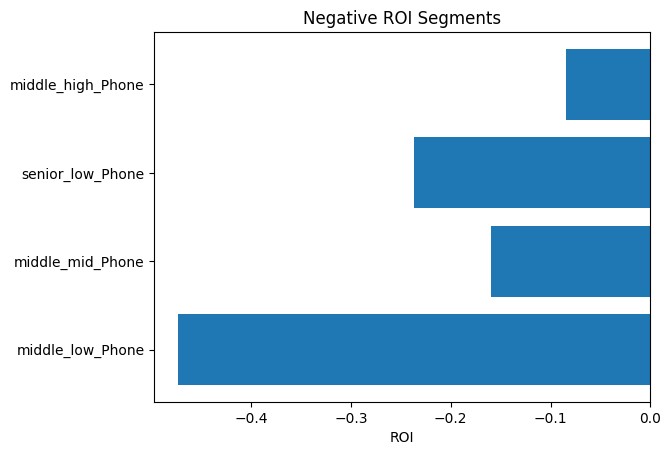

In [19]:
df = results["negative_roi_segments"]

df["segment"] = df["age_group"] + "_" + df["balance_segment"] + "_" + df["channel"]

plt.figure()
plt.barh(df["segment"], df["avg_roi"])

plt.xlabel("ROI")
plt.title("Negative ROI Segments")
plt.savefig("negative_roi_segments.png")
plt.show()

what-if simulation

In [22]:
df = pd.read_csv("/content/drive/MyDrive/marketing_roi/bank_processed.csv")

In [23]:
current_cost = df["cost"].sum()
current_revenue = df["revenue"].sum()
current_roi = current_revenue / current_cost

In [24]:
# 1. Remove Negative ROI
df_s1 = df[df["roi"] >= 0]
s1_cost = df_s1["cost"].sum()
s1_revenue = df_s1["revenue"].sum()
s1_roi = s1_revenue / s1_cost

# 2. Campaign Cap
df_s2 = df[df["campaign"] <= 3]
s2_cost = df_s2["cost"].sum()
s2_revenue = df_s2["revenue"].sum()
s2_roi = s2_revenue / s2_cost

# 3. Remove Phone
df_s3 = df[df["channel"] != "Phone"]
s3_cost = df_s3["cost"].sum()
s3_revenue = df_s3["revenue"].sum()
s3_roi = s3_revenue / s3_cost

# 4. Top 20% Segment-Channel
grouped = df.groupby(["age_group","balance_segment","channel"], as_index=False)["roi"].mean()
top = grouped.sort_values("roi", ascending=False).head(int(len(grouped)*0.2))

df_s4 = df.merge(top, on=["age_group","balance_segment","channel"])
s4_cost = df_s4["cost"].sum()
s4_revenue = df_s4["revenue"].sum()
s4_roi = s4_revenue / s4_cost

In [25]:
results = pd.DataFrame({
    "scenario": [
        "Current",
        "Remove Negative ROI",
        "Campaign Cap (<=3)",
        "Remove Phone",
        "Top 20% Focus"
    ],
    "total_cost": [
        current_cost,
        s1_cost,
        s2_cost,
        s3_cost,
        s4_cost
    ],
    "total_revenue": [
        current_revenue,
        s1_revenue,
        s2_revenue,
        s3_revenue,
        s4_revenue
    ],
    "ROI": [
        current_roi,
        s1_roi,
        s2_roi,
        s3_roi,
        s4_roi
    ]
})

results["ROI_change"] = results["ROI"] - current_roi

display(results)

,scenario,total_cost,total_revenue,ROI,ROI_change
0,Current,304498.5,264450.0,0.868477,0.000000
1,Remove Negative ROI,27394.9,263800.0,9.629530,8.761052
2,Campaign Cap (<=3),141637.3,229000.0,1.616806,0.748329
3,Remove Phone,74203.5,166550.0,2.244503,1.376026
4,Top 20% Focus,3180.0,18900.0,5.943396,5.074919


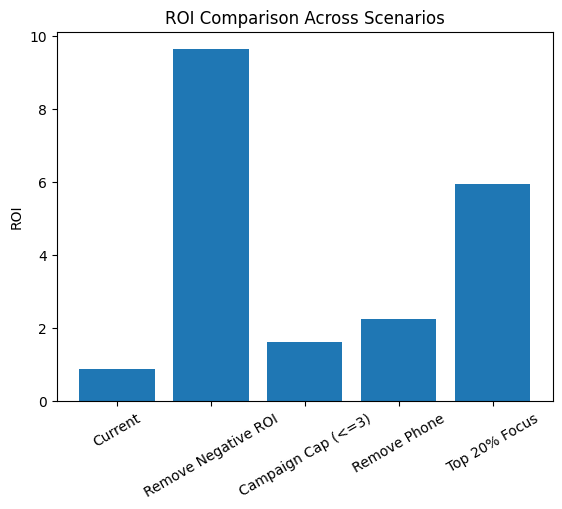

In [27]:
plt.figure()
plt.bar(results["scenario"], results["ROI"])

plt.xticks(rotation=30)
plt.ylabel("ROI")
plt.title("ROI Comparison Across Scenarios")

plt.savefig("whatifscenario.png")
plt.show()